In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns


In [2]:
file = "/home/zhe2/FraLab/PACE_redSIF_PACE/demo_example/pseudo_measurement/sif_addition_output/interim_20250927T123954_sif_addition_retrieval.nc"
ds = xr.open_dataset(file)
# lat and lon
lat = ds["latitude"]
lon = ds["longitude"]
# truth added sif
sif_added_truth = ds["sif_added_678nm"]
# retrieval sif (raw w/o addition)
sif_retrieval = ds["sif_radiance_678nm_without_sif"]
# retrieved sif (w/ addition)
sif_retrieval_added = ds["sif_radiance_678nm_with_sif"]
# difference
sif_diff = sif_retrieval_added - sif_retrieval


In [3]:
ds

<xarray.Dataset> Size: 418MB
Dimensions:                         (scans: 1710, pixels: 1272, state: 15,
                                     sif_nev: 1)
Dimensions without coordinates: scans, pixels, state, sif_nev
Data variables: (12/27)
    latitude                        (scans, pixels) float32 9MB ...
    longitude                       (scans, pixels) float32 9MB ...
    sif_added_678nm                 (scans, pixels) float32 9MB ...
    x_hat_with_sif                  (state, scans, pixels) float32 131MB ...
    converged_with_sif              (scans, pixels) uint8 2MB ...
    status_code_with_sif            (scans, pixels) int16 4MB ...
    ...                              ...
    sif_coeffs_without_sif          (sif_nev, scans, pixels) float32 9MB ...
    sif_radiance_678nm_without_sif  (scans, pixels) float32 9MB ...
    is_dark                         (scans, pixels) uint8 2MB ...
    is_ocean                        (scans, pixels) uint8 2MB ...
    source_pixel_index              (pixels) int32 5kB ...
    source_scan_index               (scans) int32 7kB ...
Attributes:
    title:            PACE SIF addition experiment (with and without SIF retr...
    history:          Created 2026-03-11T22:30:27
    input_pace_file:  /home/zhe2/FraLab/PACE_redSIF_PACE/demo_example/pseudo_...
    config_file:      /home/zhe2/FraLab/PACE_redSIF_PACE/demo_example/pseudo_...
    state_names_csv:  vcd_o2_intercept,vcd_o2_slope,vcd_h2o_intercept,vcd_h2o...
    pixel_start:      1
    pixel_end:        1272
    scan_start:       1
    scan_end:         1710

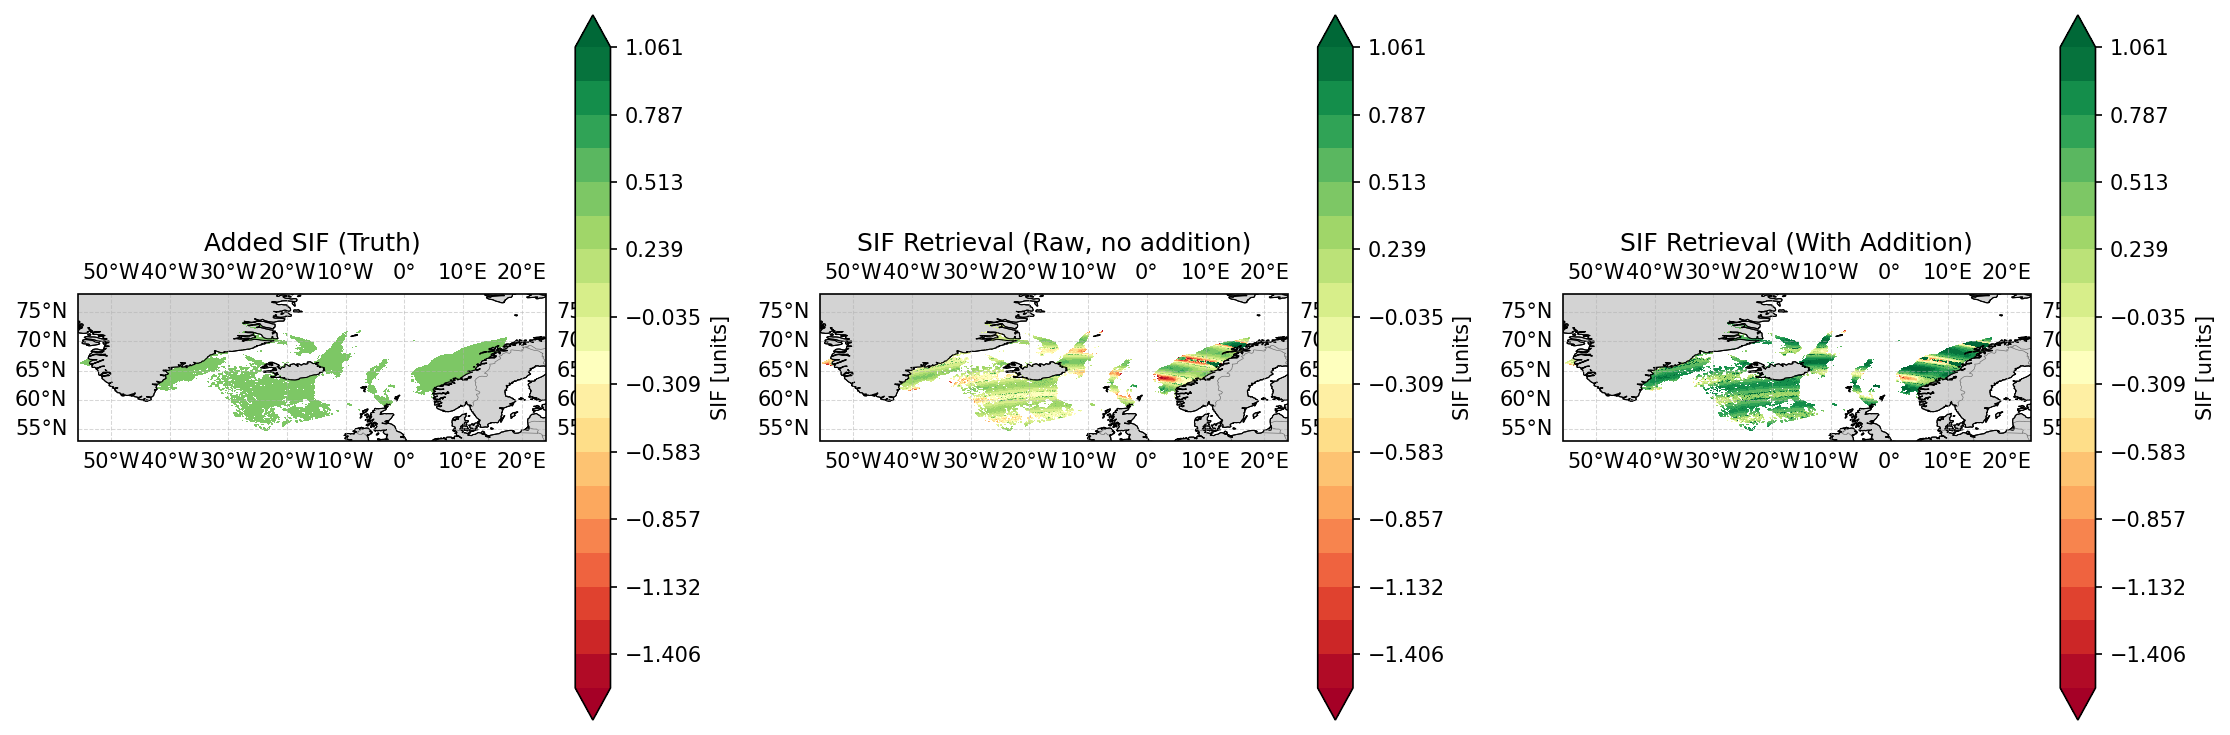

In [3]:
fig = plt.figure(figsize=(15, 5), dpi=150)

# Set extent (same as example)
buffer_bnd = 0.25
lon_min = float(lon.min()) - buffer_bnd
lon_max = float(lon.max()) + buffer_bnd
lat_min = float(lat.min()) - buffer_bnd
lat_max = float(lat.max()) + buffer_bnd
extent = [lon_min, lon_max, lat_min, lat_max]

# Prepare levels for all plots using combined percentiles for consistency
combined = np.concatenate([
    np.ravel(sif_added_truth),
    np.ravel(sif_retrieval),
    np.ravel(sif_retrieval_added)
])
levels = np.linspace(
    np.nanpercentile(combined, 0.5),
    np.nanpercentile(combined, 99.5), 20
)

proj = ccrs.PlateCarree()
cmap = 'RdYlGn'

# Plot 1: Added SIF (Truth)
ax1 = plt.subplot(1, 3, 1, projection=proj)
ax1.set_title("Added SIF (Truth)")
ax1.set_extent(extent, crs=proj)
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
im1 = ax1.contourf(lon, lat, sif_added_truth, levels=levels, transform=proj, cmap=cmap, extend='both')
cbar1 = plt.colorbar(im1, ax=ax1, orientation='vertical', label="SIF [units]")

# Plot 2: Raw SIF (Retrieval without addition)
ax2 = plt.subplot(1, 3, 2, projection=proj)
ax2.set_title("SIF Retrieval (Raw, no addition)")
ax2.set_extent(extent, crs=proj)
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
im2 = ax2.contourf(lon, lat, sif_retrieval, levels=levels, transform=proj, cmap=cmap, extend='both')
cbar2 = plt.colorbar(im2, ax=ax2, orientation='vertical', label="SIF [units]")

# Plot 3: SIF w/ addition (Retrieved + Added SIF)
ax3 = plt.subplot(1, 3, 3, projection=proj)
ax3.set_title("SIF Retrieval (With Addition)")
ax3.set_extent(extent, crs=proj)
ax3.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax3.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax3.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
im3 = ax3.contourf(lon, lat, sif_retrieval_added, levels=levels, transform=proj, cmap=cmap, extend='both')
cbar3 = plt.colorbar(im3, ax=ax3, orientation='vertical', label="SIF [units]")

plt.tight_layout()
plt.show()

(-0.5, 1.5)

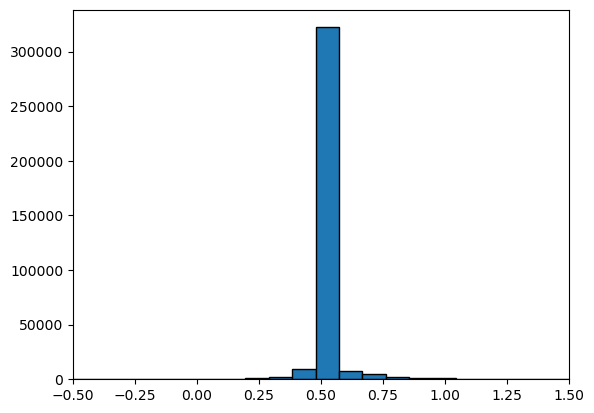

In [7]:
# plot a histogram of sif_diff
plt.hist(sif_diff.values.flatten(), bins=100, edgecolor='black')
plt.xlim(-0.5, 1.5)